In [1]:
import pandas as pd


In [3]:
df= pd.read_csv("cookie_cats.csv")

In [6]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [7]:
df.shape

(90189, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [9]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [10]:
df[["retention_1", "retention_7"]].describe()

,retention_1,retention_7
count,90189,90189
unique,2,2
top,False,False
freq,50036,73408


In [11]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["userid"].nunique()

90189

In [14]:
len(df)

90189

In [15]:
# Check version groups
print("Version values:")
print(df["version"].unique())

print("\nVersion counts:")
print(df["version"].value_counts())


# Check user IDs
print("\nUnique users:")
print(df["userid"].nunique())

print("\nDuplicate user IDs:")
print(df["userid"].duplicated().sum())


# Check game rounds
print("\nGame rounds statistics:")
print(df["sum_gamerounds"].describe())

print("\nTop 10 game round values:")
print(df["sum_gamerounds"].sort_values(ascending=False).head(10))


# Check Day 1 retention
print("\nDay 1 retention values:")
print(df["retention_1"].unique())

print("\nDay 1 retention counts:")
print(df["retention_1"].value_counts())

print("\nDay 1 retention percentages:")
print(df["retention_1"].value_counts(normalize=True) * 100)


# Check Day 7 retention
print("\nDay 7 retention values:")
print(df["retention_7"].unique())

print("\nDay 7 retention counts:")
print(df["retention_7"].value_counts())

print("\nDay 7 retention percentages:")
print(df["retention_7"].value_counts(normalize=True) * 100)


# Data types
print("\nData types:")
print(df.dtypes)

Version values:
['gate_30' 'gate_40']

Version counts:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Unique users:
90189

Duplicate user IDs:
0

Game rounds statistics:
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Top 10 game round values:
57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
46344     2251
87007     2156
36933     2124
88328     2063
6536      2015
Name: sum_gamerounds, dtype: int64

Day 1 retention values:
[False  True]

Day 1 retention counts:
retention_1
False    50036
True     40153
Name: count, dtype: int64

Day 1 retention percentages:
retention_1
False    55.47905
True     44.52095
Name: proportion, dtype: float64

Day 7 retention values:
[False  True]

Day 7 retention counts:
retention_7
False    73408
True     16781
Name: count, dtype: int64

Day 7 r

In [17]:
#Invalid game rounds
print("\nNegative game rounds:")
print((df["sum_gamerounds"] < 0).sum())


#  Game rounds range
print("\nGame rounds:")
print("Minimum:", df["sum_gamerounds"].min())
print("Maximum:", df["sum_gamerounds"].max())


#  Extreme game-round values
print("\nTop 10 game-round values:")
print(df.nlargest(10, "sum_gamerounds")[["userid", "version", "sum_gamerounds"]])



Negative game rounds:
0

Game rounds:
Minimum: 0
Maximum: 49854

Top 10 game-round values:
        userid  version  sum_gamerounds
57702  6390605  gate_30           49854
7912    871500  gate_30            2961
29417  3271615  gate_40            2640
43671  4832608  gate_30            2438
48188  5346171  gate_40            2294
46344  5133952  gate_30            2251
87007  9640085  gate_30            2156
36933  4090246  gate_40            2124
88328  9791599  gate_40            2063
6536    725080  gate_40            2015


In [18]:
#  CONTROL VS TREATMENT BALANCE

# 1. Group sizes
group_counts = df["version"].value_counts()

print("Group counts:")
print(group_counts)


# 2. Group percentages
group_percentages = df["version"].value_counts(normalize=True) * 100

print("\nGroup percentages:")
print(group_percentages)


# 3. Game-round statistics by group
print("\nGame-round statistics by group:")
print(
    df.groupby("version")["sum_gamerounds"].describe()
)


# 4. Median game rounds by group
print("\nMedian game rounds:")
print(
    df.groupby("version")["sum_gamerounds"].median()
)


# 5. Mean game rounds by group
print("\nMean game rounds:")
print(
    df.groupby("version")["sum_gamerounds"].mean()
)

Group counts:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Group percentages:
version
gate_40    50.437415
gate_30    49.562585
Name: proportion, dtype: float64

Game-round statistics by group:
           count       mean         std  min  25%   50%   75%      max
version                                                               
gate_30  44700.0  52.456264  256.716423  0.0  5.0  17.0  50.0  49854.0
gate_40  45489.0  51.298776  103.294416  0.0  5.0  16.0  52.0   2640.0

Median game rounds:
version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64

Mean game rounds:
version
gate_30    52.456264
gate_40    51.298776
Name: sum_gamerounds, dtype: float64


In [19]:
#  INSPECT THE EXTREME ANOMALY

anomaly = df[df["sum_gamerounds"] == df["sum_gamerounds"].max()]

print(anomaly)

        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True


In [20]:
# Remove the extreme anomaly
df_clean = df[df["sum_gamerounds"] != df["sum_gamerounds"].max()].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 90189
Cleaned rows: 90188
Rows removed: 1


In [21]:
print("\nMaximum game rounds after cleaning:")
print(df_clean["sum_gamerounds"].max())


Maximum game rounds after cleaning:
2961


In [22]:
#  RE-CHECK GROUP BALANCE AFTER CLEANING

#  Group counts
print("Group counts:")
print(df_clean["version"].value_counts())


#  Group percentages
print("\nGroup percentages:")
print(df_clean["version"].value_counts(normalize=True) * 100)


#  Game-round statistics
print("\nGame-round statistics by group:")
print(
    df_clean.groupby("version")["sum_gamerounds"].describe()
)


#  Median game rounds
print("\nMedian game rounds:")
print(
    df_clean.groupby("version")["sum_gamerounds"].median()
)


#  Mean game rounds
print("\nMean game rounds:")
print(
    df_clean.groupby("version")["sum_gamerounds"].mean()
)

Group counts:
version
gate_40    45489
gate_30    44699
Name: count, dtype: int64

Group percentages:
version
gate_40    50.437974
gate_30    49.562026
Name: proportion, dtype: float64

Game-round statistics by group:
           count       mean         std  min  25%   50%   75%     max
version                                                              
gate_30  44699.0  51.342111  102.057598  0.0  5.0  17.0  50.0  2961.0
gate_40  45489.0  51.298776  103.294416  0.0  5.0  16.0  52.0  2640.0

Median game rounds:
version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64

Mean game rounds:
version
gate_30    51.342111
gate_40    51.298776
Name: sum_gamerounds, dtype: float64


In [23]:
#  DAY-1 RETENTION

d1_retention = (
    df_clean.groupby("version")["retention_1"]
    .mean()
)

print("Day-1 Retention:")
print(d1_retention * 100)

Day-1 Retention:
version
gate_30    44.819795
gate_40    44.228275
Name: retention_1, dtype: float64


In [24]:
# Number of users and retained users

d1_summary = df_clean.groupby("version").agg(
    total_users=("userid", "count"),
    retained_users_d1=("retention_1", "sum")
)

d1_summary["retention_rate"] = (
    d1_summary["retained_users_d1"] /
    d1_summary["total_users"]
)

print(d1_summary)

         total_users  retained_users_d1  retention_rate
version                                                
gate_30        44699              20034        0.448198
gate_40        45489              20119        0.442283


In [25]:
control_d1 = d1_retention["gate_30"]
treatment_d1 = d1_retention["gate_40"]

d1_difference = treatment_d1 - control_d1

print("Control D1 retention:", control_d1)
print("Treatment D1 retention:", treatment_d1)
print("Difference:", d1_difference)
print("Difference in percentage points:", d1_difference * 100)

Control D1 retention: 0.4481979462627799
Treatment D1 retention: 0.44228274967574577
Difference: -0.005915196587034155
Difference in percentage points: -0.5915196587034155


In [26]:
# DAY-7 RETENTION

d7_retention = (
    df_clean.groupby("version")["retention_7"]
    .mean()
)

print("Day-7 Retention:")
print(d7_retention * 100)

Day-7 Retention:
version
gate_30    19.018323
gate_40    18.200004
Name: retention_7, dtype: float64


In [27]:
control_d7 = d7_retention["gate_30"]
treatment_d7 = d7_retention["gate_40"]

d7_difference = treatment_d7 - control_d7

print("Control D7 retention:", control_d7)
print("Treatment D7 retention:", treatment_d7)
print("Difference:", d7_difference)
print("Difference in percentage points:", d7_difference * 100)

Control D7 retention: 0.19018322557551623
Treatment D7 retention: 0.18200004396667327
Difference: -0.00818318160884296
Difference in percentage points: -0.818318160884296


In [28]:
from statsmodels.stats.proportion import proportions_ztest

In [29]:
# D1 TWO-PROPORTION Z-TEST

d1_counts = df_clean.groupby("version")["retention_1"].sum()
d1_totals = df_clean.groupby("version")["retention_1"].count()

count = [
    d1_counts["gate_30"],
    d1_counts["gate_40"]
]

nobs = [
    d1_totals["gate_30"],
    d1_totals["gate_40"]
]

z_stat_d1, p_value_d1 = proportions_ztest(
    count,
    nobs,
    alternative="two-sided"
)

print("D1 Z-statistic:", z_stat_d1)
print("D1 P-value:", p_value_d1)

D1 Z-statistic: 1.787103509763628
D1 P-value: 0.0739207603418346


In [30]:
#D7 TWO-PROPORTION Z-TEST

d7_counts = df_clean.groupby("version")["retention_7"].sum()
d7_totals = df_clean.groupby("version")["retention_7"].count()

count = [
    d7_counts["gate_30"],
    d7_counts["gate_40"]
]

nobs = [
    d7_totals["gate_30"],
    d7_totals["gate_40"]
]

z_stat_d7, p_value_d7 = proportions_ztest(
    count,
    nobs,
    alternative="two-sided"
)

print("D7 Z-statistic:", z_stat_d7)
print("D7 P-value:", p_value_d7)

D7 Z-statistic: 3.1574100858819936
D7 P-value: 0.0015917731773993442


In [31]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Function to calculate CI for difference in proportions
def proportion_difference_ci(success_control, total_control,
                             success_treatment, total_treatment,
                             confidence=0.95):

    p_control = success_control / total_control
    p_treatment = success_treatment / total_treatment

    difference = p_treatment - p_control

    se = np.sqrt(
        (p_control * (1 - p_control) / total_control) +
        (p_treatment * (1 - p_treatment) / total_treatment)
    )

    z = 1.96

    lower = difference - z * se
    upper = difference + z * se

    return difference, lower, upper

In [32]:
d1_diff, d1_lower, d1_upper = proportion_difference_ci(
    d1_counts["gate_30"],
    d1_totals["gate_30"],
    d1_counts["gate_40"],
    d1_totals["gate_40"]
)

print("D1 difference:", d1_diff)
print("D1 95% CI:", d1_lower, d1_upper)
print("D1 95% CI percentage points:",
      d1_lower * 100,
      d1_upper * 100)

D1 difference: -0.005915196587034155
D1 95% CI: -0.01240262898665639 0.0005722358125880792
D1 95% CI percentage points: -1.240262898665639 0.05722358125880792


In [33]:
d7_diff, d7_lower, d7_upper = proportion_difference_ci(
    d7_counts["gate_30"],
    d7_totals["gate_30"],
    d7_counts["gate_40"],
    d7_totals["gate_40"]
)

print("D7 difference:", d7_diff)
print("D7 95% CI:", d7_lower, d7_upper)
print("D7 95% CI percentage points:",
      d7_lower * 100,
      d7_upper * 100)

D7 difference: -0.00818318160884296
D7 95% CI: -0.013263463260905021 -0.0031028999567808985
D7 95% CI percentage points: -1.3263463260905022 -0.31028999567808985


In [34]:
import numpy as np

np.random.seed(42)

control_d1_data = df_clean[
    df_clean["version"] == "gate_30"
]["retention_1"].values

treatment_d1_data = df_clean[
    df_clean["version"] == "gate_40"
]["retention_1"].values


bootstrap_d1 = []

for _ in range(10000):

    control_sample = np.random.choice(
        control_d1_data,
        size=len(control_d1_data),
        replace=True
    )

    treatment_sample = np.random.choice(
        treatment_d1_data,
        size=len(treatment_d1_data),
        replace=True
    )

    control_rate = control_sample.mean()
    treatment_rate = treatment_sample.mean()

    difference = treatment_rate - control_rate

    bootstrap_d1.append(difference)


bootstrap_d1 = np.array(bootstrap_d1)

print("Bootstrap iterations:", len(bootstrap_d1))
print("Mean bootstrap difference:", bootstrap_d1.mean())

Bootstrap iterations: 10000
Mean bootstrap difference: -0.0059403420937773265


In [35]:
d1_bootstrap_lower = np.percentile(
    bootstrap_d1, 2.5
)

d1_bootstrap_upper = np.percentile(
    bootstrap_d1, 97.5
)

print("D1 Bootstrap 95% CI:")
print(
    d1_bootstrap_lower * 100,
    "to",
    d1_bootstrap_upper * 100,
    "percentage points"
)

D1 Bootstrap 95% CI:
-1.2526872826553948 to 0.047909732321062465 percentage points


In [36]:
np.random.seed(42)

control_d7_data = df_clean[
    df_clean["version"] == "gate_30"
]["retention_7"].values

treatment_d7_data = df_clean[
    df_clean["version"] == "gate_40"
]["retention_7"].values


bootstrap_d7 = []

for _ in range(10000):

    control_sample = np.random.choice(
        control_d7_data,
        size=len(control_d7_data),
        replace=True
    )

    treatment_sample = np.random.choice(
        treatment_d7_data,
        size=len(treatment_d7_data),
        replace=True
    )

    control_rate = control_sample.mean()
    treatment_rate = treatment_sample.mean()

    difference = treatment_rate - control_rate

    bootstrap_d7.append(difference)


bootstrap_d7 = np.array(bootstrap_d7)

print("Bootstrap iterations:", len(bootstrap_d7))
print("Mean bootstrap difference:", bootstrap_d7.mean())

Bootstrap iterations: 10000
Mean bootstrap difference: -0.008190440865372583


In [37]:
d7_bootstrap_lower = np.percentile(
    bootstrap_d7, 2.5
)

d7_bootstrap_upper = np.percentile(
    bootstrap_d7, 97.5
)

print("D7 Bootstrap 95% CI:")
print(
    d7_bootstrap_lower * 100,
    "to",
    d7_bootstrap_upper * 100,
    "percentage points"
)

D7 Bootstrap 95% CI:
-1.3258741647696246 to -0.31744158670920575 percentage points


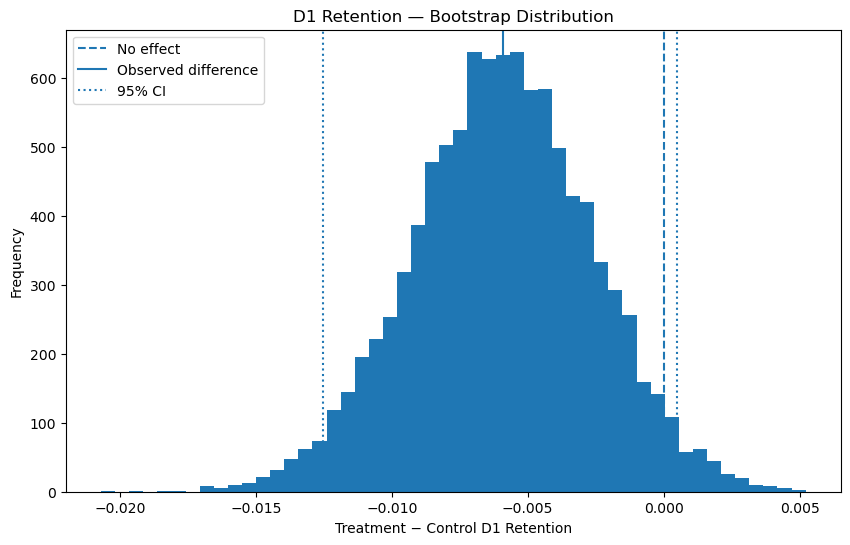

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    bootstrap_d1,
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    label="No effect"
)

plt.axvline(
    d1_diff,
    linestyle="-",
    label="Observed difference"
)

plt.axvline(
    d1_bootstrap_lower,
    linestyle=":",
    label="95% CI"
)

plt.axvline(
    d1_bootstrap_upper,
    linestyle=":"
)

plt.xlabel("Treatment − Control D1 Retention")
plt.ylabel("Frequency")
plt.title("D1 Retention — Bootstrap Distribution")
plt.legend()

plt.show()

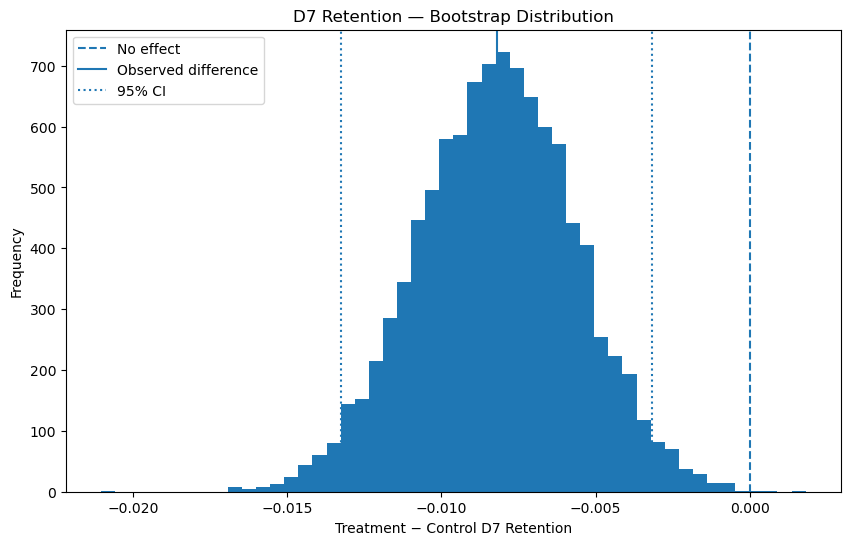

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(
    bootstrap_d7,
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    label="No effect"
)

plt.axvline(
    d7_diff,
    linestyle="-",
    label="Observed difference"
)

plt.axvline(
    d7_bootstrap_lower,
    linestyle=":",
    label="95% CI"
)

plt.axvline(
    d7_bootstrap_upper,
    linestyle=":"
)

plt.xlabel("Treatment − Control D7 Retention")
plt.ylabel("Frequency")
plt.title("D7 Retention — Bootstrap Distribution")
plt.legend()

plt.show()

In [41]:
practical_effect_d7 = (
    treatment_d7 - control_d7
) * 1_000_000

print("D7 practical effect per 1M players:",
      practical_effect_d7)

D7 practical effect per 1M players: -8183.18160884296


In [42]:
practical_effect_d1 = (
    treatment_d1 - control_d1
) * 1_000_000

print("D1 practical effect per 1M players:",
      practical_effect_d1)

D1 practical effect per 1M players: -5915.196587034155
